## 8ª Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 11 de abril de 2026  

---

### Descrição
Exercícios computacionais

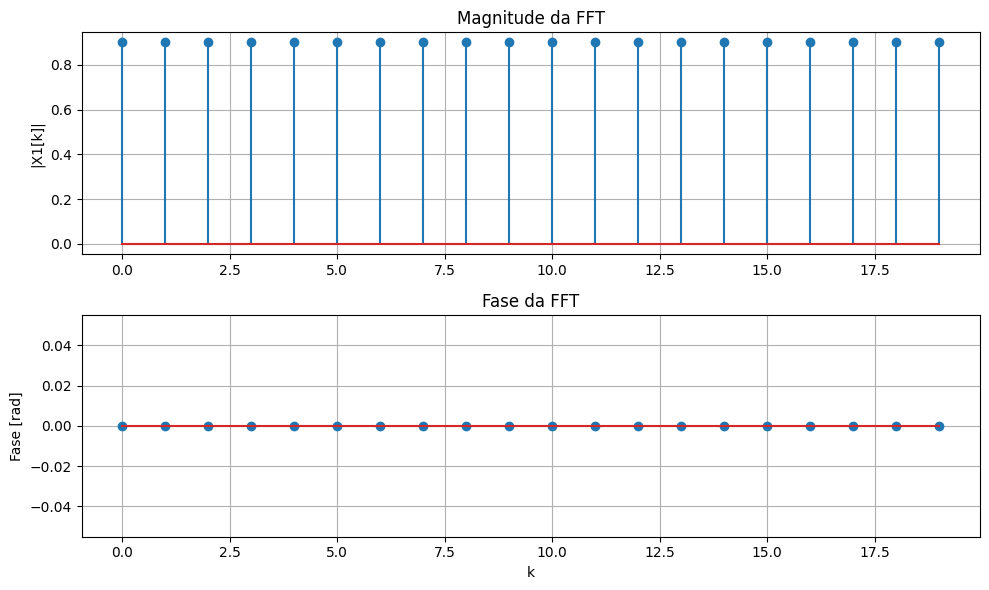

In [ ]:
"""
    1. Gere o sinal x1[n] = 0.9δ[n], 0 ≤ n ≤ 19. Plote o gráfico de magnitude e fase 
    da FFT calculada. Os resultados estão coerentes com o que você esperava? Comente.
"""

import numpy as np
import matplotlib.pyplot as plt

N = 20
n = np.arange(N)

x1 = np.zeros(N)
x1[0] = 0.9
X1 = np.fft.fft(x1)

k = np.arange(N)

magnitude = np.abs(X1)
fase = np.angle(X1)

# Gráficos
plt.figure(figsize=(10, 6))

# Magnitude
plt.subplot(2, 1, 1)
plt.stem(k, magnitude)
plt.title('Magnitude da FFT')
plt.ylabel('|X1[k]|')
plt.grid(True)

# Fase
plt.subplot(2, 1, 2)
plt.stem(k, fase)
plt.title('Fase da FFT')
plt.xlabel('k')
plt.ylabel('Fase [rad]')
plt.grid(True)
plt.tight_layout()

plt.show()

"Os resultados são coerentes com a teoria. Como a DFT de um impulso na origem é uma constante "
"X1[k]=0.9 para todo k, a magnitude obtida é exatamente 0.9 em todas as frequências "
"e a fase é nula, confirmando que o espectro é plano e sem deslocamento de fase."


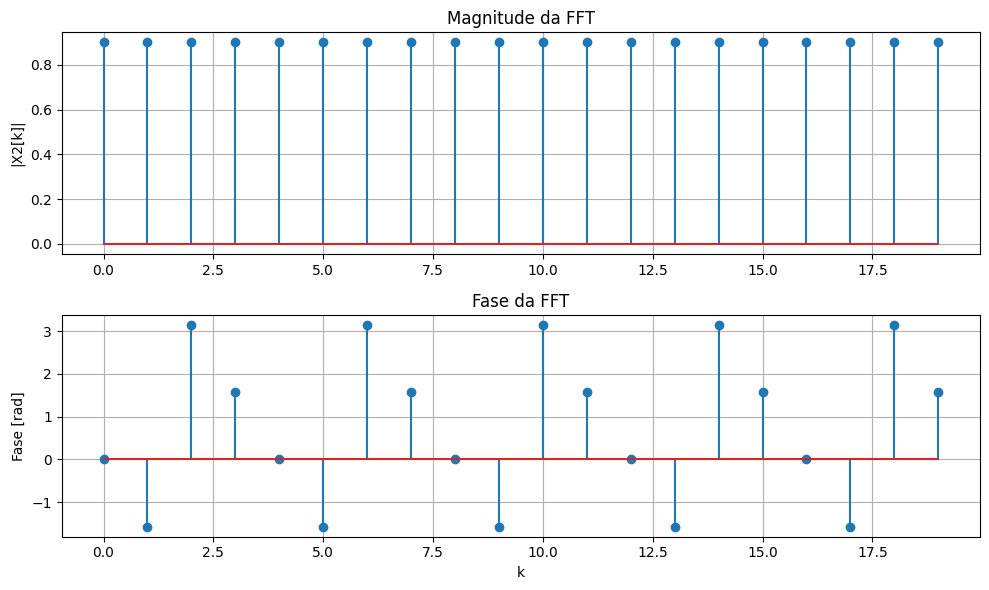

In [1]:
"""
   2. Gere agora o sinal x2[n] = 0.9δ[n - 5], 0 ≤ n ≤ 19. Plote o gráfico de magnitude e fase
    da FFT calculada. Comente. 
"""

import numpy as np
import matplotlib.pyplot as plt

N = 20
n = np.arange(N)

x2 = np.zeros(N)
x2[5] = 0.9
X2 = np.fft.fft(x2)
k = np.arange(N)

magnitude = np.abs(X2)
fase = np.angle(X2)

plt.figure(figsize=(10, 6))

# Magnitude
plt.subplot(2,1,1)
plt.stem(k, magnitude)
plt.title('Magnitude da FFT')
plt.ylabel('|X2[k]|')
plt.grid(True)

# Fase
plt.subplot(2,1,2)
plt.stem(k, fase)
plt.title('Fase da FFT')
plt.xlabel('k')
plt.ylabel('Fase [rad]')
plt.grid(True)

plt.tight_layout()
plt.show()

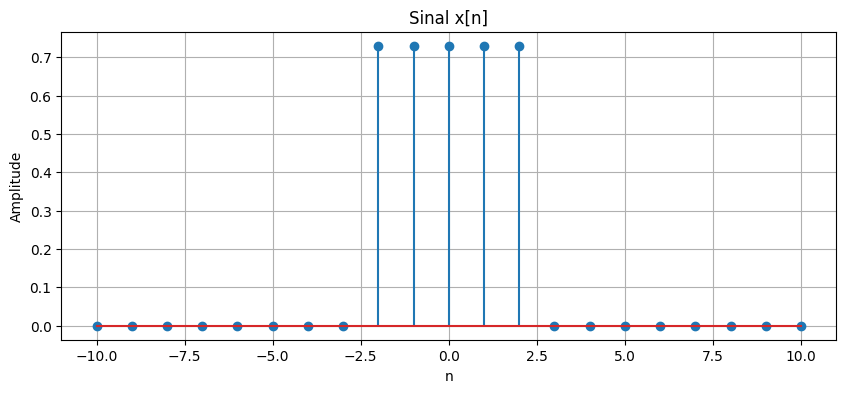

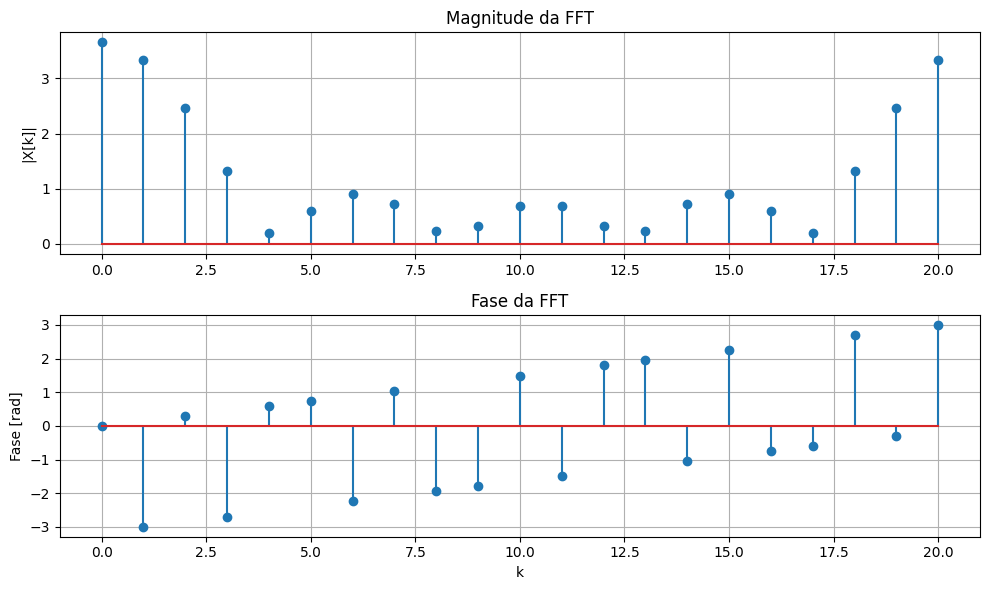

In [2]:
"""
    3. Gere um sinal do seu interesse e plote a magnitude e fase da FFT.

    Sinal de meu interesse: x[n] = {0.73, -2 <= n <= 2
                                   {0, caso contrário
    com -10 <= n <= 10
"""

import numpy as np
import matplotlib.pyplot as plt

n = np.arange(-10, 11)
x = np.zeros(len(n))
x[(n >= -2) & (n <= 2)] = 0.73
X = np.fft.fft(x)
k = np.arange(len(X))

magnitude = np.abs(X)
fase = np.angle(X)

# Plot do sinal
plt.figure(figsize=(10,4))
plt.stem(n, x)
plt.title('Sinal x[n]')
plt.xlabel('n')
plt.ylabel('Amplitude')
plt.grid(True)

# FFT
plt.figure(figsize=(10,6))

# Magnitude
plt.subplot(2,1,1)
plt.stem(k, magnitude)
plt.title('Magnitude da FFT')
plt.ylabel('|X[k]|')
plt.grid(True)

# Fase
plt.subplot(2,1,2)
plt.stem(k, fase)
plt.title('Fase da FFT')
plt.xlabel('k')
plt.ylabel('Fase [rad]')
plt.grid(True)

plt.tight_layout()
plt.show()

/usr/local/python/3.12.1/lib/python3.12/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


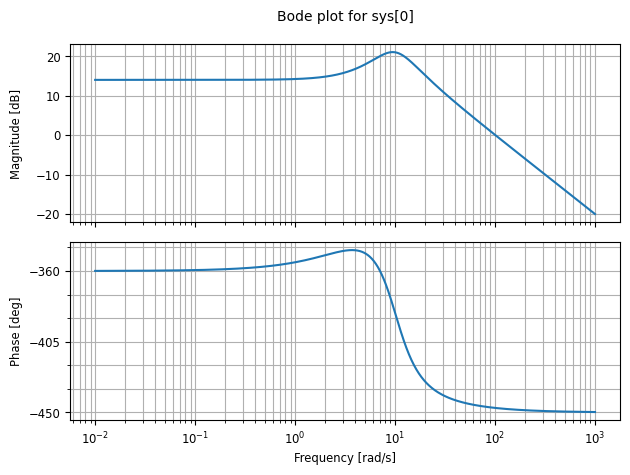

/usr/local/python/3.12.1/lib/python3.12/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


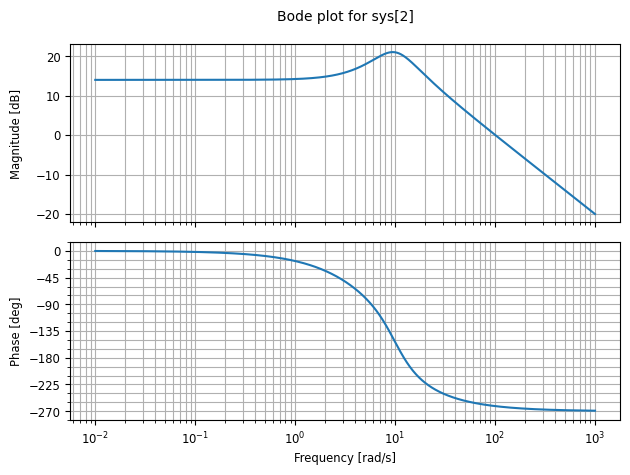

/usr/local/python/3.12.1/lib/python3.12/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


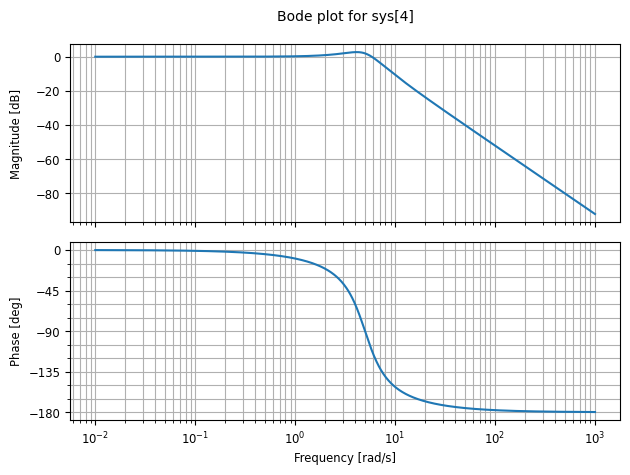

/usr/local/python/3.12.1/lib/python3.12/site-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


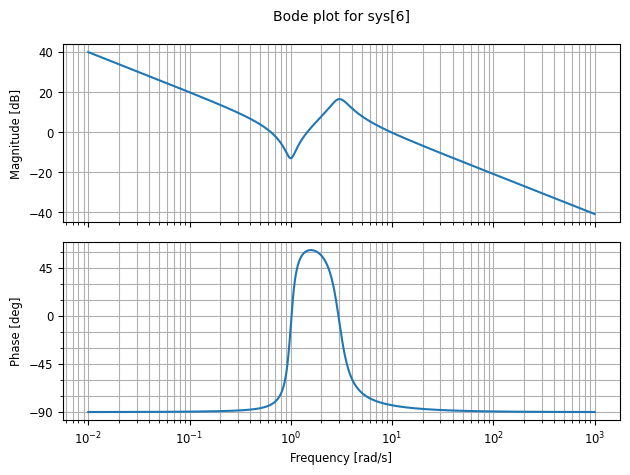

'\nO sistema possui um integrador, dois zeros e dois polos complexos, resultando em múltiplas mudanças na inclinação do \ndiagrama de magnitude. Em baixas frequências, o integrador provoca decaimento de -20 dB/dec, enquanto os zeros e \npolos modificam esse comportamento ao longo da faixa de frequências. A fase apresenta variações mais acentuadas devido \nà combinação desses elementos dinâmicos.\n'

In [1]:
"""
    4. Construa e comente o diagrama de Bode de módulo e fase de:

    a)  G(s) = (100[s+5])/(s²+10s+100)
    b)  G(s) = (-100[s+5])/(s²+10s+100)
    c)  G(s) = (25)/(s²+4s+25)
    d)  G(s) = (9[s²+0.2s+1])/(s[s²+1.2s+9]), no intervalo 0,01 <= w <= 1000
"""

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl


# ITEM a)
G_a = ctrl.tf([100, 500], [1, 10, 100])
w_a = np.logspace(-2, 3, 1000)
mag_a, phase_a, omega_a = ctrl.bode(G_a, w_a, dB=True, deg=True, plot=True)

plt.show()

"""
O sistema apresenta um zero em s=-5 e dois polos complexos no denominador. Em baixas frequências, o ganho permanece 
aproximadamente constante, enquanto em altas frequências ocorre decaimento de aproximadamente -20 dB/dec, resultado 
combinado do efeito de um zero e dois polos. A fase tende a valores negativos, aproximando-se de -90°.
"""

# ITEM b)
G_b = ctrl.tf([-100, 500], [1, 10, 100])
w_b = np.logspace(-2, 3, 1000)
mag_b, phase_b, omega_b = ctrl.bode(G_b, w_b, dB=True, deg=True, plot=True)

plt.show()

"""
O diagrama de magnitude é idêntico ao do item (a), pois multiplicar a função de transferência por -1 não altera o 
módulo. Entretanto, a fase sofre um deslocamento adicional de aproximadamente 180°, devido ao sinal negativo 
presente no numerador.
"""

# ITEM c)
G_c = ctrl.tf([25], [1, 4, 25])
w_c = np.logspace(-2, 3, 1000)
mag_c, phase_c, omega_c = ctrl.bode(G_c, w_c, dB=True, deg=True, plot=True)

plt.show()

"""
Trata-se de um sistema de segunda ordem sem zeros finitos. O ganho permanece aproximadamente constante em baixas 
frequências e passa a decair com inclinação de -40 dB/dec em altas frequências, devido aos dois polos do sistema. 
A fase varia gradualmente de 0° para -180°, podendo haver um pequeno pico de ressonância próximo da frequência natural.
"""

# ITEM d)
G_d = ctrl.tf([9, 1.8, 9], [1, 1.2, 9, 0])
w_d = np.logspace(-2, 3, 1000)
mag_d, phase_d, omega_d = ctrl.bode(G_d, w_d, dB=True, deg=True, plot=True)

plt.show()

"""
O sistema possui um integrador, dois zeros e dois polos complexos, resultando em múltiplas mudanças na inclinação do 
diagrama de magnitude. Em baixas frequências, o integrador provoca decaimento de -20 dB/dec, enquanto os zeros e 
polos modificam esse comportamento ao longo da faixa de frequências. A fase apresenta variações mais acentuadas devido 
à combinação desses elementos dinâmicos.
"""

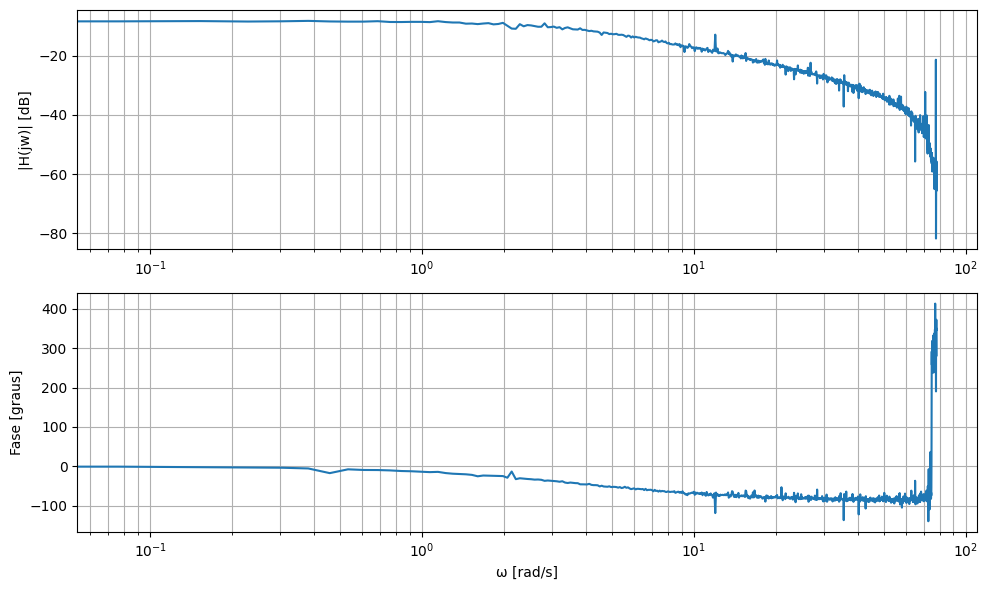

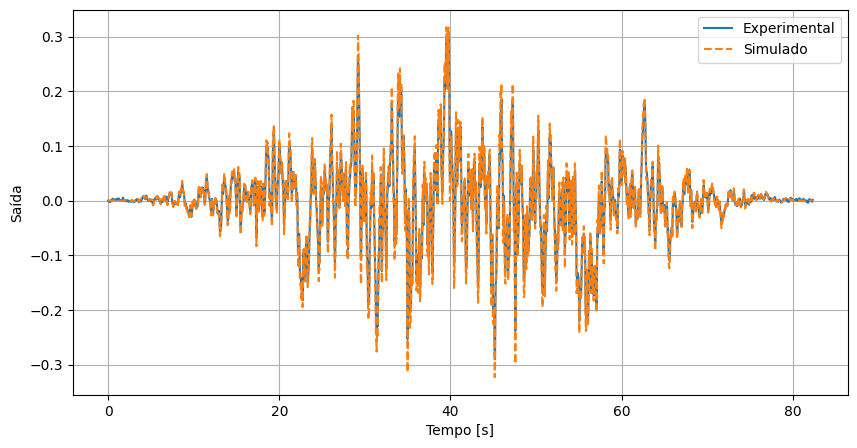

'\nA saída simulada apresentou comportamento próximo da saída experimental, indicando que a função de transferência \nestimada representa adequadamente a dinâmica do sistema.\n'

In [2]:
"""
    5. Neste exercício o intuito é identificar dois sistemas lineares e determinar suas respectivas
    funções de transferência a partir de sinais de entrada e saída obtidos experimentalmente.
    É escolhido um sinal de entrada rico em frequências para excitar o sistema na maior banda
    de frequências possível. A saída está sujeita a um ruído de medida da ordem de -40dB.
    O sinal de entrada foi passado por uma função janela para suavizar os efeitos do número
    finito de amostras. Os dados para dois sistemas diferentes são fornecidos nos arquivos
    exp1.mat e exp2.mat. Para cada um dos arquivos, siga as instruções abaixo e apresente
    como solução a função de transferência estimada para o sistema.
"""

# PARA ARQUIVO exp1.mat

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import control as ctrl

# Carregar arquivo
data = loadmat('exp1.mat')

# Extrair variáveis
u = data['u'].flatten()
y = data['y'].flatten()
t = data['time'].flatten()

# Número de amostras
N = len(t)

# Tempo de amostragem
Ts = t[1] - t[0]

# Frequências angulares
w = 2 * np.pi * np.arange(N) / (N * Ts)


U = np.fft.fft(u)
Y = np.fft.fft(y)

# Função de transferência estimada
H = Y / U


plt.figure(figsize=(10,6))

# Magnitude
plt.subplot(2,1,1)
plt.semilogx(w[:N//2], 20*np.log10(np.abs(H[:N//2])))
plt.ylabel('|H(jw)| [dB]')
plt.grid(True, which='both')

# Fase
plt.subplot(2,1,2)
plt.semilogx(
    w[:N//2],
    np.unwrap(np.angle(H[:N//2])) * 180/np.pi
)

plt.ylabel('Fase [graus]')
plt.xlabel('ω [rad/s]')
plt.grid(True, which='both')

# Plot do Diagrama
plt.tight_layout()
plt.show()

"""
    Como é possível análisar no diagrama a quedra de 20dB/dec, temos que o sistema é de primeira ordem. Agora temos que
    descobrir a função de tranferência de sistema.
"""
# Ganho e TF
K = np.abs(H[0])
a = 5 #Hz. Foi o que consegui analisar
G = ctrl.tf([K*a], [1, a])

t_out, y_sim = ctrl.forced_response(G, T=t, U=u)

# Plot das duas saídas.
plt.figure(figsize=(10,5))

plt.plot(t, y, label='Experimental')
plt.plot(t, y_sim, '--', label='Simulado')

plt.xlabel('Tempo [s]')
plt.ylabel('Saída')

plt.legend()
plt.grid(True)

plt.show()

"""
A saída simulada apresentou comportamento próximo da saída experimental, indicando que a função de transferência 
estimada representa adequadamente a dinâmica do sistema.
"""




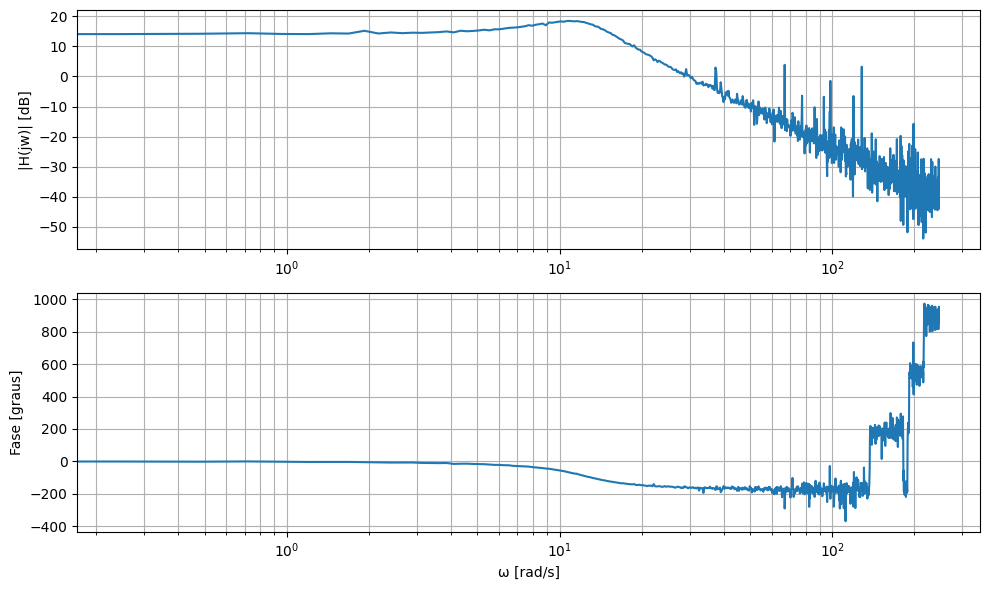

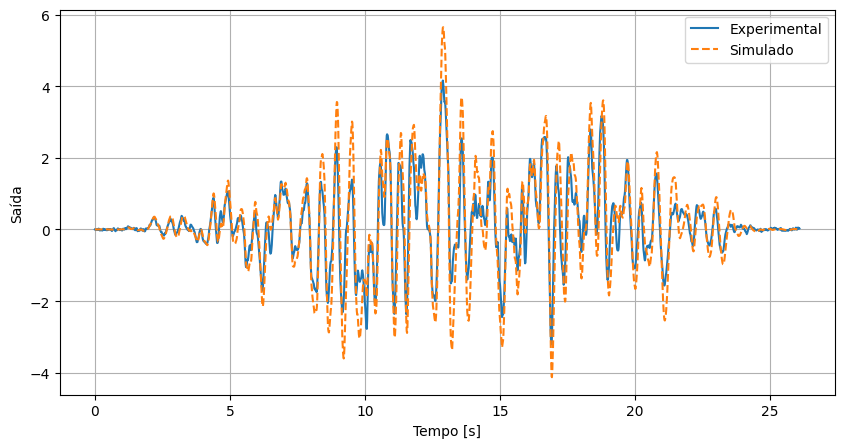

In [ ]:
# PARA ARQUIVO exp2.mat

import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import control as ctrl

# Carregar arquivo
data = loadmat('exp2.mat')

# Extrair variáveis
u = data['u'].flatten()
y = data['y'].flatten()
t = data['time'].flatten()

# Número de amostras
N = len(t)

# Tempo de amostragem
Ts = t[1] - t[0]

# Frequências angulares
w = 2 * np.pi * np.arange(N) / (N * Ts)


U = np.fft.fft(u)
Y = np.fft.fft(y)

# Função de transferência estimada
H = Y / U


plt.figure(figsize=(10,6))

# Magnitude
plt.subplot(2,1,1)
plt.semilogx(w[:N//2], 20*np.log10(np.abs(H[:N//2])))
plt.ylabel('|H(jw)| [dB]')
plt.grid(True, which='both')

# Fase
plt.subplot(2,1,2)
plt.semilogx(
    w[:N//2],
    np.unwrap(np.angle(H[:N//2])) * 180/np.pi
)

plt.ylabel('Fase [graus]')
plt.xlabel('ω [rad/s]')
plt.grid(True, which='both')

# Plot do Diagrama
plt.tight_layout()
plt.show()

"""
    Como é possível análisar no diagrama a quedra de 40dB/dec e a "saliencia no pico", temos que o sistema é de segunda ordem. Agora temos que
    descobrir a função de tranferência de sistema.
"""

# Pico de Ressonancia
mag = np.abs(H[:N//2])
Mp = np.max(mag) / mag[0]
# Frequencia de ressonancia
idx = np.argmax(mag)
wr = w[idx]
# Amortecimento
xi = abs(np.log(Mp)) / np.sqrt(np.pi**2 + (np.log(Mp))**2)
# Frequencia Natural
wn = wr / np.sqrt(1 - 2*xi**2)
# Ganho
K = mag[0]

# TF
G = ctrl.tf(
    [K*wn**2],
    [1, 2*xi*wn, wn**2]
)


# Simular respost
t_out, y_sim = ctrl.forced_response(G, T=t, U=u)

plt.figure(figsize=(10,5))

plt.plot(t, y, label='Experimental')
plt.plot(t, y_sim, '--', label='Simulado')

plt.xlabel('Tempo [s]')
plt.ylabel('Saída')

plt.legend()
plt.grid(True)

plt.show()

"""
    Pequenas diferenças entre os sinais podem ser atribuídas ao ruído experimental e às aproximações 
    realizadas na identificação dos parâmetros do sistema.
"""


